# Cox-Time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn_pandas import DataFrameMapper
import torch
import torchtuples as tt

from pycox.models.cox_time import MLPVanillaCoxTime
from pycox.models import CoxTime
from pycox.evaluation import EvalSurv

In [2]:
SEED = 50

In [3]:
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

## Dataset

In [ ]:
from dataset_NCT00981058 import DatasetNCT00981058

ds_name = 'real_NCT00981058_inject'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_NCT00981058_inject'
SAVE_PATH = f'./pycox_models/more_g/{project}/cox_time_pycox_more_g_{SEED}'
g_resol = 1
t_resol = 7
split = 'train'
ds = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_train = ds._get_df_Xy_trans_obs_more_g()

split = 'test'
ds = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_test = ds._get_df_Xy_true_prob()

split = 'val'
ds = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_val = ds._get_df_Xy_trans_obs_more_g()

In [5]:
df_test

,subject,duration,g_max_by_time,event_observed,weight,feat__AGE,feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS,feat__BMIBL,feat__BSABL,feat__Body Surface Area (m^2),...,feat__SMKB_Smoker (all others),feat__SOCIAL CIRCUMSTANCES,feat__SURGICAL AND MEDICAL PROCEDURES,feat__Systolic Blood Pressure (mmHg),feat__Temperature (°C),feat__VASCULAR DISORDERS,"feat__WBCCAT1_> 11,000 µl (11 x 10^9/L)",feat__Weight (kg),feat__traj_clust,is_t_trans
0,b'014-7882',0,1,0.0,1,-0.347338,0.0,-0.860482,-0.415036,-0.415036,...,1.0,0.0,0.333333,0.905439,1.755901,0.666667,0.0,-0.662496,0.0,NaN
1,b'014-7882',1,1,NaN,1,-0.347338,0.0,-0.860482,-0.415036,-0.415036,...,1.0,0.0,0.333333,0.905439,1.755901,0.666667,0.0,-0.662496,0.0,NaN
2,b'014-7882',2,1,1.0,1,-0.347338,0.0,-0.860482,-0.415036,-0.415036,...,1.0,0.0,0.333333,0.905439,1.755901,0.666667,0.0,-0.662496,0.0,NaN
3,b'014-7882',3,1,1.0,1,-0.347338,0.0,-0.860482,-0.415036,-0.415036,...,1.0,0.0,0.333333,0.905439,1.755901,0.666667,0.0,-0.662496,0.0,NaN
4,b'014-7882',4,1,1.0,1,-0.347338,0.0,-0.860482,-0.415036,-0.415036,...,1.0,0.0,0.333333,0.905439,1.755901,0.666667,0.0,-0.662496,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81995,b'721-7880',159,5,NaN,1,0.625361,0.0,0.819803,1.545583,1.545583,...,1.0,0.0,0.333333,0.063363,-0.120828,0.333333,0.0,1.273058,0.5,NaN
81996,b'721-7880',160,5,NaN,1,0.625361,0.0,0.819803,1.545583,1.545583,...,1.0,0.0,0.333333,0.063363,-0.120828,0.333333,0.0,1.273058,0.5,NaN
81997,b'721-7880',161,5,NaN,1,0.625361,0.0,0.819803,1.545583,1.545583,...,1.0,0.0,0.333333,0.063363,-0.120828,0.333333,0.0,1.273058,0.5,NaN
81998,b'721-7880',162,5,NaN,1,0.625361,0.0,0.819803,1.545583,1.545583,...,1.0,0.0,0.333333,0.063363,-0.120828,0.333333,0.0,1.273058,0.5,NaN


In [6]:
df_train.head()

,subject,event_observed,duration,g_max_by_time,feat__AGE,feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS,feat__BMIBL,feat__BSABL,feat__Body Surface Area (m^2),feat__CARDIAC DISORDERS,...,feat__SOCIAL CIRCUMSTANCES,feat__SURGICAL AND MEDICAL PROCEDURES,feat__Systolic Blood Pressure (mmHg),feat__Temperature (°C),feat__VASCULAR DISORDERS,"feat__WBCCAT1_> 11,000 µl (11 x 10^9/L)",feat__Weight (kg),feat__traj_clust,weight,is_t_trans
0,b'001-7882',1,2.0,2.0,-0.712101,0.666667,-0.911691,0.110984,0.110984,0.0,...,0.0,0.666667,-1.685565,-0.746404,0.0,0.0,-0.381528,0.25,1,1
1,b'001-7882',1,15.0,4.0,-0.712101,0.666667,-0.911691,0.110984,0.110984,0.0,...,0.0,0.666667,-1.685565,-0.746404,0.0,0.0,-0.381528,0.25,1,1
2,b'008-7881',1,4.0,1.0,-0.347338,0.000000,0.000045,-0.032476,-0.032476,0.0,...,0.0,0.000000,-1.361689,-1.580505,0.0,1.0,-0.100561,0.50,1,1
3,b'008-7881',0,62.0,2.0,-0.347338,0.000000,0.000045,-0.032476,-0.032476,0.0,...,0.0,0.000000,-1.361689,-1.580505,0.0,1.0,-0.100561,0.50,1,1
4,b'008-7881',0,62.0,3.0,-0.347338,0.000000,0.000045,-0.032476,-0.032476,0.0,...,0.0,0.000000,-1.361689,-1.580505,0.0,1.0,-0.100561,0.50,1,1


## Feature transforms

In [7]:
x_train = df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].astype('float32')
x_train['g_max_by_time'] = x_train['g_max_by_time']/ds.g_max
x_train = x_train.values

x_val = df_val.loc[:,df_val.columns.str.startswith('feat')|df_val.columns.str.startswith('g_max_by_time')].astype('float32')
x_val['g_max_by_time'] = x_val['g_max_by_time']/ds.g_max
x_val = x_val.values

x_test = df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].drop_duplicates().astype('float32')
x_test['g_max_by_time'] = x_test['g_max_by_time']/ds.g_max
x_test = x_test.values



In [8]:
df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].columns == (
    df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].columns
)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

We need no label transforms

In [9]:
get_target = lambda df: (df['duration'].astype('float32').values, df['event_observed'].astype('float32').values)
y_train = get_target(df_train)
y_val = get_target(df_val)
durations_test, events_test = get_target(df_test)
val = tt.tuplefy(x_val, y_val)

In [10]:
val.shapes()

((333, 53), ((333,), (333,)))

With `TupleTree` (the results of `tt.tuplefy`) we can easily repeat the validation dataset multiple times. This will be useful for reduce the variance of the validation loss, as the validation loss of `CoxTime` is not deterministic.

In [11]:
val.repeat(2).cat().shapes()

((666, 53), ((666,), (666,)))

## Neural net
 
We create a simple MLP with two hidden layers, ReLU activations, batch norm and dropout. 
The net required by `CoxTime` is slightly different than most of the other methods as it also take `time` and an additional input argument. 
We have therefore crated the `MLPVanillaCoxTime` class that is a suitable version of `tt.practical.MLPVanilla`.
This class also removes the options for setting `out_features` and `output_bias` as they should be `1` and `False`, respectively.
 
To see the code for the networks call `??MLPVanillaCoxTime`.

In [12]:
in_features = x_train.shape[1]
num_nodes = [64, 64, 64, 64]
batch_norm = False
dropout = 0

net = MLPVanillaCoxTime(in_features, num_nodes, batch_norm, dropout)

## Training the model

In [13]:
model = CoxTime(net, tt.optim.Adam(lr=1e-2, weight_decay=1e-2))

In [14]:
batch_size = 16

We include the `EarlyStopping` callback to stop training when the validation loss stops improving. After training, this callback will also load the best performing model in terms of validation loss.

In [15]:
epochs = 2000
callbacks = [tt.callbacks.EarlyStopping(patience=500)]
verbose = True

In [16]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val.repeat(10).cat())

0:	[0s / 0s],		train_loss: 0.7015,	val_loss: 0.6682
1:	[0s / 0s],		train_loss: 0.6080,	val_loss: 0.4995
2:	[0s / 0s],		train_loss: 0.5338,	val_loss: 0.4634
3:	[0s / 0s],		train_loss: 0.4943,	val_loss: 0.5000
4:	[0s / 0s],		train_loss: 0.4731,	val_loss: 0.4754
5:	[0s / 1s],		train_loss: 0.4742,	val_loss: 0.5271
6:	[0s / 1s],		train_loss: 0.5019,	val_loss: 0.5064
7:	[0s / 1s],		train_loss: 0.4966,	val_loss: 0.5004
8:	[0s / 1s],		train_loss: 0.4597,	val_loss: 0.4757
9:	[0s / 1s],		train_loss: 0.4775,	val_loss: 0.4857
10:	[0s / 1s],		train_loss: 0.5239,	val_loss: 0.4644
11:	[0s / 1s],		train_loss: 0.4889,	val_loss: 0.4715
12:	[0s / 2s],		train_loss: 0.4856,	val_loss: 0.5020
13:	[0s / 2s],		train_loss: 0.5078,	val_loss: 0.4484
14:	[0s / 2s],		train_loss: 0.4821,	val_loss: 0.4754
15:	[0s / 2s],		train_loss: 0.5141,	val_loss: 0.4899
16:	[0s / 2s],		train_loss: 0.4780,	val_loss: 0.4594
17:	[0s / 2s],		train_loss: 0.4518,	val_loss: 0.4101
18:	[0s / 2s],		train_loss: 0.4606,	val_loss: 0.4518
19:

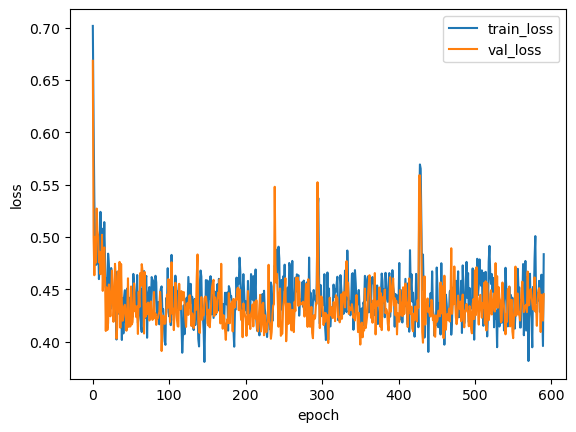

In [17]:
_ = log.plot()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.savefig(f'{SAVE_PATH}_training_curves.pdf')
log.to_pandas().to_csv(f'{SAVE_PATH}_training_curves.csv')

We can get the partial log-likelihood

In [18]:
model.partial_log_likelihood(*val).mean()

-4.6197524

## Prediction

For evaluation we first need to obtain survival estimates for the test set.
This can be done with `model.predict_surv` which returns an array of survival estimates, or with `model.predict_surv_df` which returns the survival estimates as a dataframe.

However, as `CoxCC` is semi-parametric, we first need to get the non-parametric baseline hazard estimates with `compute_baseline_hazards`. 

Note that for large datasets the `sample` argument can be used to estimate the baseline hazard on a subset.

In [19]:
_ = model.compute_baseline_hazards()

In [20]:
x_test.shape

(500, 53)

In [21]:
x_test

array([[ 0.2       , -0.3473384 ,  0.        , ...,  0.        ,
        -0.66249573,  0.        ],
       [ 0.4       , -0.3473384 ,  0.        , ...,  0.        ,
        -0.66249573,  0.        ],
       [ 0.6       , -0.3473384 ,  0.        , ...,  0.        ,
        -0.66249573,  0.        ],
       ...,
       [ 0.6       ,  0.62536067,  0.        , ...,  0.        ,
         1.2730577 ,  0.5       ],
       [ 0.8       ,  0.62536067,  0.        , ...,  0.        ,
         1.2730577 ,  0.5       ],
       [ 1.        ,  0.62536067,  0.        , ...,  0.        ,
         1.2730577 ,  0.5       ]], dtype=float32)

In [22]:
surv = model.predict_surv_df(x_test)

In [23]:
surv

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
duration,,,,,,,,,,,,,,,,,,,,,
1.0,8.462483e-01,0.963062,0.991550,0.998089,0.999569,8.359276e-01,0.960401,0.990932,0.997948,0.999537,...,8.386827e-01,0.961114,0.991098,0.997986,0.999546,0.918604,0.981041,0.995694,0.999028,0.999781
2.0,5.249552e-01,0.864780,0.967777,0.992643,0.998337,5.008592e-01,0.855658,0.965466,0.992108,0.998215,...,5.071386e-01,0.858064,0.966077,0.992249,0.998247,0.720427,0.928738,0.983471,0.996249,0.999153
3.0,4.119742e-01,0.818801,0.955931,0.989891,0.997712,3.981788e-01,0.806992,0.952804,0.989159,0.997546,...,3.929012e-01,0.810088,0.953626,0.989352,0.997589,0.636868,0.903279,0.977327,0.994843,0.998835
4.0,3.353654e-01,0.781692,0.945989,0.987560,0.997182,3.377557e-01,0.773564,0.942498,0.986664,0.996978,...,3.163625e-01,0.771471,0.943184,0.986899,0.997031,0.573614,0.882226,0.972144,0.993651,0.998565
5.0,3.177014e-01,0.772215,0.943391,0.986948,0.997043,3.256256e-01,0.766325,0.940223,0.986052,0.996829,...,2.988392e-01,0.761624,0.940456,0.986255,0.996885,0.558068,0.876773,0.970786,0.993338,0.998494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170.0,2.247820e-11,0.001902,0.201647,0.664141,0.900897,1.707991e-07,0.018631,0.361700,0.771373,0.935864,...,4.465044e-15,0.000215,0.116046,0.577386,0.869236,0.000011,0.053973,0.474279,0.826416,0.952454
176.0,2.247820e-11,0.001902,0.201647,0.664141,0.900897,1.707991e-07,0.018631,0.361700,0.771373,0.935864,...,4.465044e-15,0.000215,0.116046,0.577386,0.869236,0.000011,0.053973,0.474279,0.826416,0.952454
221.0,2.247820e-11,0.001902,0.201647,0.664141,0.900897,1.707991e-07,0.018631,0.361700,0.771373,0.935864,...,4.465044e-15,0.000215,0.116046,0.577386,0.869236,0.000011,0.053973,0.474279,0.826416,0.952454


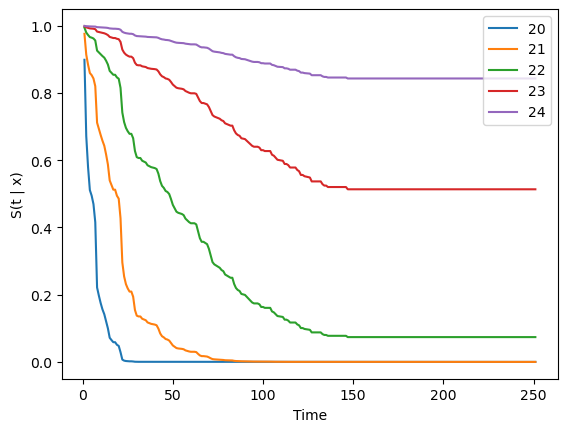

In [24]:
n = 5
surv.iloc[:, 5*(n-1):5*n].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

In [25]:
model.save_net(SAVE_PATH)